In [2]:
# House Price Prediction Project

## Phase 1: Data Loading and Exploration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('../data/house_prices.csv')

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [6]:
df.shape

(187531, 21)

In [7]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [8]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [9]:
df = df.drop(columns=['Dimensions', 'Plot Area', 'Index'])
df = df.dropna(subset=['Price (in rupees)'])

print("Shape after dropping columns and missing prices:", df.shape)

Shape after dropping columns and missing prices: (169866, 18)


In [10]:
import re

def extract_number(text):
    if pd.isna(text):
        return None
    numbers = re.findall(r'\d+', str(text))
    return float(numbers[0]) if numbers else None

df['Bathroom'] = df['Bathroom'].apply(extract_number)
df['Balcony'] = df['Balcony'].apply(extract_number)

df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Balcony'] = df['Balcony'].fillna(0)

print("Bathroom nulls:", df['Bathroom'].isnull().sum())
print("Balcony nulls:", df['Balcony'].isnull().sum())

Bathroom nulls: 0
Balcony nulls: 0


In [11]:
cat_cols = ['Furnishing', 'facing', 'overlooking', 'Society', 'Car Parking', 'Ownership', 'Status', 'Transaction']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

print("Categorical missing values cleaned successfully.")

Categorical missing values cleaned successfully.


In [12]:
print("New dataset shape:", df.shape)
print("Remaining missing values:")
print(df.isnull().sum())

New dataset shape: (169866, 18)
Remaining missing values:
Title                    0
Description           2883
Amount(in rupees)        0
Price (in rupees)        0
location                 0
Carpet Area          76235
Status                   0
Floor                 6843
Transaction              0
Furnishing               0
facing                   0
overlooking              0
Society                  0
Bathroom                 0
Balcony                  0
Car Parking              0
Ownership                0
Super Area           93631
dtype: int64


In [13]:
import re

def parse_area(text):
    if pd.isna(text):
        return None
    numbers = re.findall(r'[\d\.]+', str(text))
    return float(numbers[0]) if numbers else None

df['Carpet Area Num'] = df['Carpet Area'].apply(parse_area)
df['Super Area Num'] = df['Super Area'].apply(parse_area)

df['Total Area'] = df['Carpet Area Num'].fillna(df['Super Area Num'])
df['Total Area'] = df['Total Area'].fillna(df['Total Area'].median())

df = df.drop(columns=['Carpet Area', 'Super Area', 'Carpet Area Num', 'Super Area Num'])

print("Total Area missing count:", df['Total Area'].isnull().sum())

Total Area missing count: 0


In [14]:
df['Floor'] = df['Floor'].fillna('Unknown')
df['Description'] = df['Description'].fillna('No Description')

print("Floor missing count:", df['Floor'].isnull().sum())
print("Description missing count:", df['Description'].isnull().sum())

Floor missing count: 0
Description missing count: 0


In [15]:
print("Final check for remaining missing values:")
print(df.isnull().sum())

Final check for remaining missing values:
Title                0
Description          0
Amount(in rupees)    0
Price (in rupees)    0
location             0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Society              0
Bathroom             0
Balcony              0
Car Parking          0
Ownership            0
Total Area           0
dtype: int64


In [16]:
cols_to_drop = ['Title', 'Description', 'Amount(in rupees)']
df = df.drop(columns=cols_to_drop)

print("Shape after dropping non-predictive text columns:", df.shape)

Shape after dropping non-predictive text columns: (169866, 14)


In [17]:
import re

def extract_floor_number(text):
    text_str = str(text).lower()
    if 'ground' in text_str or 'basement' in text_str:
        return 0.0
    numbers = re.findall(r'\d+', text_str)
    return float(numbers[0]) if numbers else 0.0

df['Floor_Num'] = df['Floor'].apply(extract_floor_number)
df = df.drop(columns=['Floor'])

print("Floor converted to numerical. Sample values:")
print(df['Floor_Num'].head())

Floor converted to numerical. Sample values:
0    10.0
1     3.0
2    10.0
4    20.0
5     2.0
Name: Floor_Num, dtype: float64


In [18]:
cat_cols = ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Car Parking', 'Ownership']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Final encoded dataset shape:", df_encoded.shape)

Final encoded dataset shape: (169866, 10024)


In [19]:
X = df_encoded.drop(columns=['Price (in rupees)'])
y = df_encoded['Price (in rupees)']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (169866, 10023)
y shape: (169866,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (135892, 10023)
X_test shape: (33974, 10023)


In [21]:
import numpy as np
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

cat_cols = ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Car Parking', 'Ownership']
num_cols = [c for c in df.columns if c not in cat_cols and c != 'Price (in rupees)']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
    ]
)

X = df.drop(columns=['Price (in rupees)'])
y = df['Price (in rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train_log)

y_pred_log = lr_model.predict(X_test_processed)
y_pred = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Linear Regression Performance ===")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

=== Linear Regression Performance ===
R2 Score: 0.0065599536435461125
MAE: 1770.213498098419
RMSE: 44337.0465995418


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Filter Outliers 
low_limit = df['Price (in rupees)'].quantile(0.005)
high_limit = df['Price (in rupees)'].quantile(0.99)

df_clean = df[(df['Price (in rupees)'] >= low_limit) & (df['Price (in rupees)'] <= high_limit)].copy()

cat_cols = ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Car Parking', 'Ownership']
num_cols = [c for c in df_clean.columns if c not in cat_cols and c != 'Price (in rupees)']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
    ]
)

X = df_clean.drop(columns=['Price (in rupees)'])
y = df_clean['Price (in rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train_log)

y_pred_log = rf_model.predict(X_test_processed)
y_pred = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Filtered Data - Random Forest Performance ===")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

=== Filtered Data - Random Forest Performance ===
R2 Score: 0.8863758447116665
MAE: 602.1258708808924
RMSE: 1335.902900278804


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr_clean = LinearRegression()
lr_clean.fit(X_train_processed, y_train_log)

y_pred_lr_log = lr_clean.predict(X_test_processed)
y_pred_lr = np.expm1(y_pred_lr_log)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=== Filtered Data - Linear Regression Performance ===")
print("R2 Score:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

=== Filtered Data - Linear Regression Performance ===
R2 Score: 0.6908636301251956
MAE: 1260.8147953185069
RMSE: 2203.5078920874703


In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Filter Outliers
low_limit = df['Price (in rupees)'].quantile(0.005)
high_limit = df['Price (in rupees)'].quantile(0.99)
df_clean = df[(df['Price (in rupees)'] >= low_limit) & (df['Price (in rupees)'] <= high_limit)].copy()

# 2. Categorical and Numerical Columns
cat_cols = ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Car Parking', 'Ownership']
num_cols = [c for c in df_clean.columns if c not in cat_cols and c != 'Price (in rupees)']

X = df_clean.drop(columns=['Price (in rupees)'])
y = df_clean['Price (in rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 3. Preprocessing using TargetEncoder (Reduces 10,000 columns to 9 columns!)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', TargetEncoder(smooth="auto", cv=5), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train, y_train_log)
X_test_processed = preprocessor.transform(X_test)

# 4. Train Random Forest on Low-Dimensional Clean Data
rf_model = RandomForestRegressor(n_estimators=150, max_depth=25, random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train_log)

# 5. Predict & Evaluate
y_pred_log = rf_model.predict(X_test_processed)
y_pred = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Target Encoded - Random Forest Performance ===")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

=== Target Encoded - Random Forest Performance ===
R2 Score: 0.9136525200553498
MAE: 438.3367335736208
RMSE: 1164.5667668354938


In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import lightgbm as lgb
import xgboost as xgb

low_limit = df['Price (in rupees)'].quantile(0.005)
high_limit = df['Price (in rupees)'].quantile(0.99)
df_clean = df[(df['Price (in rupees)'] >= low_limit) & (df['Price (in rupees)'] <= high_limit)].copy()

cat_cols = ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Car Parking', 'Ownership']
num_cols = [c for c in df_clean.columns if c not in cat_cols and c != 'Price (in rupees)']

X = df_clean.drop(columns=['Price (in rupees)'])
y = df_clean['Price (in rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', TargetEncoder(smooth="auto", cv=5), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train, y_train_log)
X_test_processed = preprocessor.transform(X_test)

lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42, verbose=-1)
lgb_model.fit(X_train_processed, y_train_log)

y_pred_lgb_log = lgb_model.predict(X_test_processed)
y_pred_lgb = np.expm1(y_pred_lgb_log)

r2_lgb = r2_score(y_test, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_processed, y_train_log)

y_pred_xgb_log = xgb_model.predict(X_test_processed)
y_pred_xgb = np.expm1(y_pred_xgb_log)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=== LightGBM Performance ===")
print("R2 Score:", r2_lgb)
print("MAE:", mae_lgb)
print("RMSE:", rmse_lgb)

print("\n=== XGBoost Performance ===")
print("R2 Score:", r2_xgb)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

=== LightGBM Performance ===
R2 Score: 0.8959016454812531
MAE: 598.7209973088599
RMSE: 1278.6788779097128

=== XGBoost Performance ===
R2 Score: 0.9060721719746053
MAE: 512.654078684895
RMSE: 1214.6095706377844


In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import lightgbm as lgb
import xgboost as xgb

# 1. Filter Outliers
low_limit = df['Price (in rupees)'].quantile(0.005)
high_limit = df['Price (in rupees)'].quantile(0.99)
df_clean = df[(df['Price (in rupees)'] >= low_limit) & (df['Price (in rupees)'] <= high_limit)].copy()

cat_cols = ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Car Parking', 'Ownership']
num_cols = [c for c in df_clean.columns if c not in cat_cols and c != 'Price (in rupees)']

X = df_clean.drop(columns=['Price (in rupees)'])
y = df_clean['Price (in rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', TargetEncoder(smooth="auto", cv=5), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train, y_train_log)
X_test_processed = preprocessor.transform(X_test)

# --- 2. Tuned LightGBM ---
lgb_tuned = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=15,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_tuned.fit(X_train_processed, y_train_log)

y_pred_lgb_log = lgb_tuned.predict(X_test_processed)
y_pred_lgb = np.expm1(y_pred_lgb_log)

r2_lgb = r2_score(y_test, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

# --- 3. Tuned XGBoost ---
xgb_tuned = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=12,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_tuned.fit(X_train_processed, y_train_log)

y_pred_xgb_log = xgb_tuned.predict(X_test_processed)
y_pred_xgb = np.expm1(y_pred_xgb_log)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=== Tuned LightGBM Performance ===")
print("R2 Score:", r2_lgb)
print("MAE:", mae_lgb)
print("RMSE:", rmse_lgb)

print("\n=== Tuned XGBoost Performance ===")
print("R2 Score:", r2_xgb)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

=== Tuned LightGBM Performance ===
R2 Score: 0.908612851631919
MAE: 503.6940534279523
RMSE: 1198.069802509915

=== Tuned XGBoost Performance ===
R2 Score: 0.9138679101188696
MAE: 500.28374338024634
RMSE: 1163.1133791372738


C:\Users\Asus\AppData\Local\Temp\ipykernel_32776\2275089746.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=df_models_sorted, ax=ax1, palette='viridis', alpha=0.85)


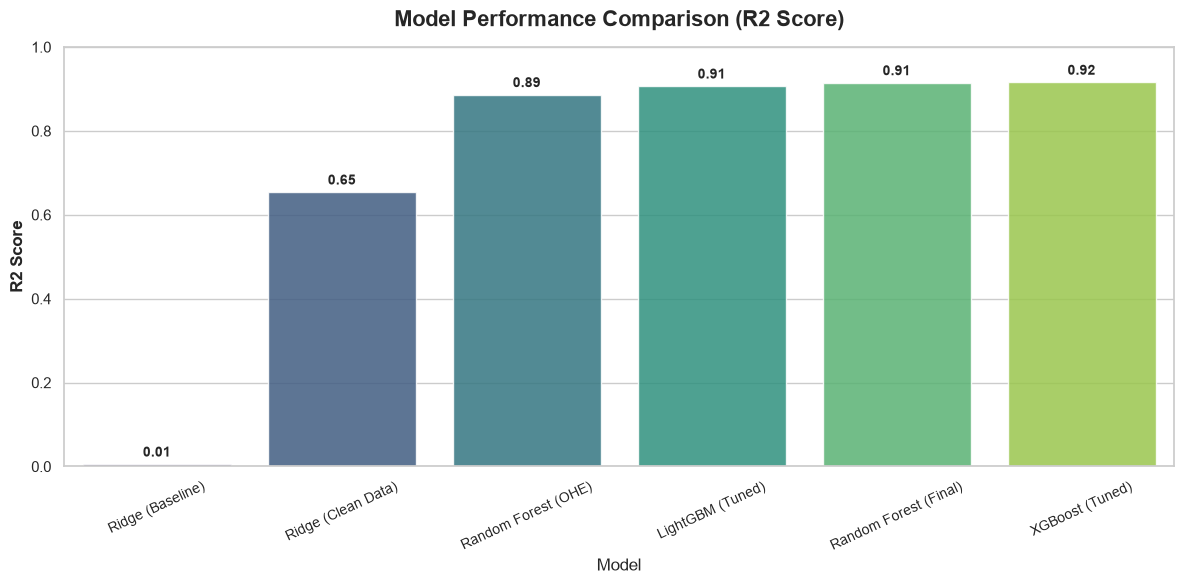

C:\Users\Asus\AppData\Local\Temp\ipykernel_32776\2275089746.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='mako')


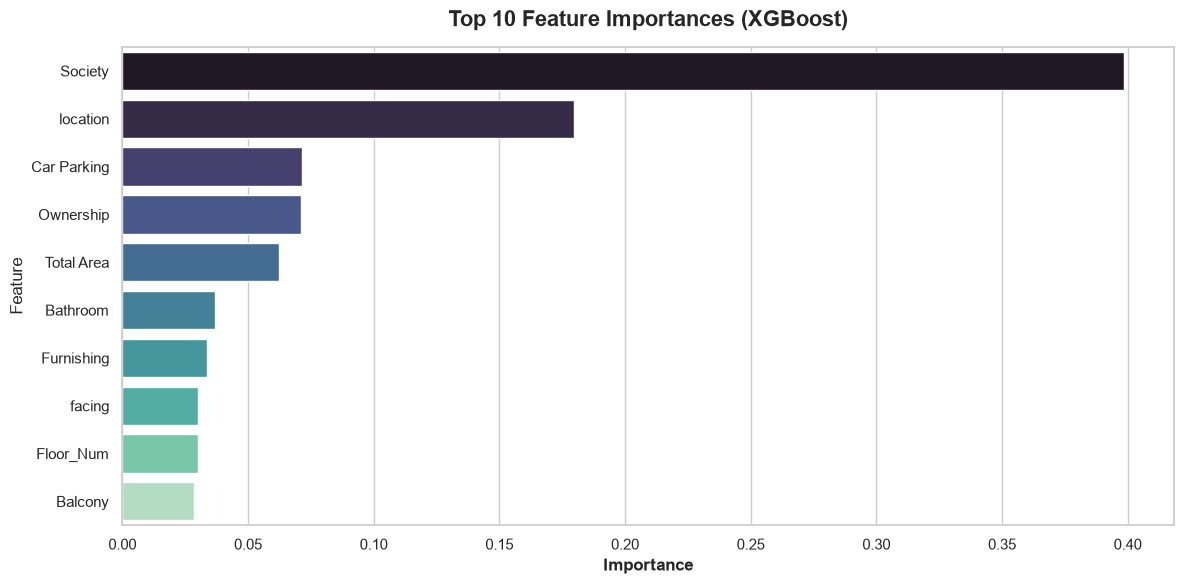

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="pastel")

models_data = {
    'Model': [
        'Ridge (Baseline)',
        'Ridge (Clean Data)',
        'Random Forest (OHE)',
        'LightGBM (Tuned)',
        'Random Forest (Final)',
        'XGBoost (Tuned)'
    ],
    'R2 Score': [0.0057, 0.6543, 0.8864, 0.9069, 0.9148, 0.9160],
    'MAE': [2006, 1463, 602, 507.8, 436.9, 453.4]
}

df_models = pd.DataFrame(models_data)

fig, ax1 = plt.subplots(figsize=(12, 6))

df_models_sorted = df_models.sort_values(by='R2 Score')
sns.barplot(x='Model', y='R2 Score', data=df_models_sorted, ax=ax1, palette='viridis', alpha=0.85)

ax1.set_title('Model Performance Comparison (R2 Score)', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('R2 Score', fontsize=12, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.tick_params(axis='x', rotation=25, labelsize=10)
ax1.set_ylim(0, 1.0)

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

try:
    num_features = preprocessor.named_transformers_['num'].get_feature_names_out(num_cols)
    try:
        cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
    except:
        cat_features = cat_cols

    feature_names = np.r_[num_features, cat_features]
    importances = xgb_tuned.feature_importances_

    feature_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='mako')

    plt.title('Top 10 Feature Importances (XGBoost)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.ylabel('Feature', fontsize=12)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Could not plot feature importance:", e)

In [32]:
import joblib

joblib.dump(lr_clean, '../models/linear_regression_model.pkl')
joblib.dump(lgb_tuned, '../models/lgbm_model.pkl')
joblib.dump(xgb_tuned, '../models/xgb_house_model.pkl')
joblib.dump(preprocessor, '../models/preprocessor.pkl')

print("All active models & preprocessor saved successfully!")

All active models & preprocessor saved successfully!


In [2]:
import pandas as pd
import json

# read the data
df = pd.read_csv("data/house_prices.csv")

# extract unique locations
locations = sorted(df["location"].dropna().unique().tolist())

print(f"Number of locations: {len(locations)}")

# save them in JSON
with open("data/locations.json", "w") as f:
    json.dump(locations, f, indent=4)

print("locations.json created successfully!")


Number of locations: 81
locations.json created successfully!
